In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
warnings.filterwarnings("ignore")
import sys
sys.path.append('/home/future_commodity')
import os
import re
from pathlib import Path
from typing import List, Tuple

import numpy as np
np.seterr(all='ignore')
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from joblib import Parallel, delayed

import function_future.pre_train as pt
import function_future.train_model as tm
import function_future.FactorFilter as FF
import function_future.backtest_v3 as bv
import function_future.DataLoader as DL
import function_future.date_selection as DS
import function_future.trading_visualization as TV

In [3]:
symbol_lst = ["P", "A", "M", "Y"]

In [4]:
train_label = 5
rtn_mul = 1

bt_params = (0.8, 0.5, 10, 5*345)
train_end_date = '2025-07-01'

In [7]:
def run_res(symbol, bt_params):
    config_loader = DL.InstrumentConfig()
    config_loader.get_instrument_config(symbol)

    config = bv.load_config(r"/mnt/Data/writable/liaoyuyang/backtest/backtest_config.json")
    config['MODEL_DIR'] = f'models/{symbol}'

    bt = bv.ModelBacktester(train_end_date, config)
    bt.load_config(symbol)
    bt.window_end = '2027-01-01'
    bt.money = 200_000 
    bt.fee = 0

    bt.load_factor(symbol, end_date=bt.window_end)
    bt.load_mktdata(symbol, end_date=bt.window_end)
    bt.load_models()
    bt.generate_predictions()
    pred = bt.combine_models('best_iteration_log_weighted', avg=True)

    th1, th2, holding_bars, day = bt_params
    merged_data = bt.backtest(th1=th1, th2=th2, save=False, open_drop=True, holding_bars=holding_bars,
                           day=day, model_name='best_iteration_log_weighted', v=2
                        )

    return merged_data

In [8]:
merged_data_lst = Parallel(n_jobs=len(symbol_lst))(delayed(run_res)(symbol, bt_params)
                                                   for symbol in symbol_lst)

trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']
trading_hours ['09:00-11:30', '13:30-15:00', '21:00-23:00']


100%|██████████| 59875/59875 [02:12<00:00, 450.50it/s]


In [9]:
def plot_all(symbol_lst, merged_data_lst):
    pnl_ret = []
    for i, merged_data in enumerate(merged_data_lst):
        symbol = symbol_lst[i]
        df = merged_data.set_index('datetime')[['equity', 'date']]
        df.name = symbol
        df = df.groupby('date').last()
        pnl_ret.append(df)
    return pd.concat(pnl_ret,axis=1).ffill()

In [10]:
merged_df_all = plot_all(symbol_lst, merged_data_lst)

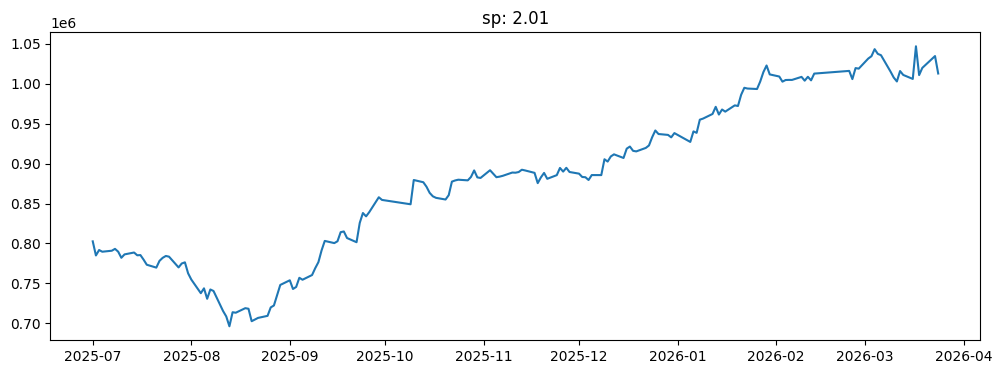

In [11]:
sp = merged_df_all.sum(axis=1).diff().mean() / merged_df_all.sum(axis=1).diff().std() * np.sqrt(252)
plt.figure(figsize=(12, 4))  # Correct way to set figure size
plt.plot(merged_df_all.sum(axis=1))
plt.title(f'sp: {round(sp,2)}')
plt.show()